In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv('diabetes.csv')

In [4]:
df.shape

(768, 9)

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

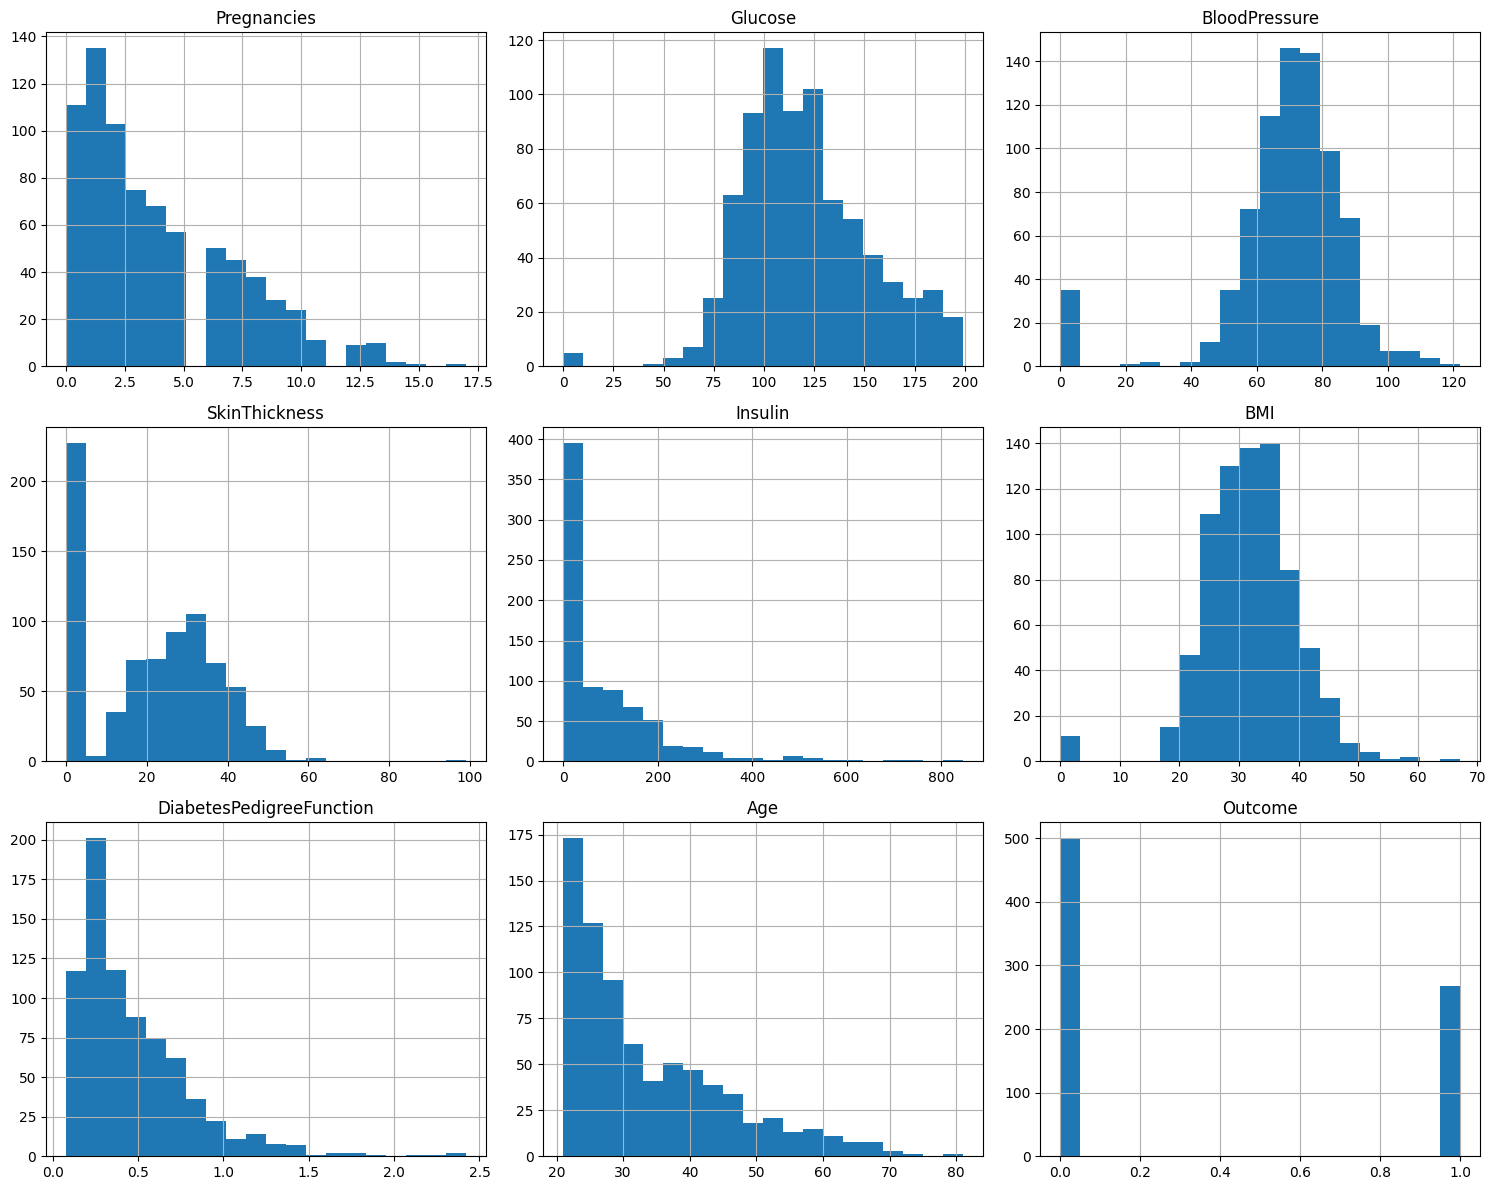

In [9]:
df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

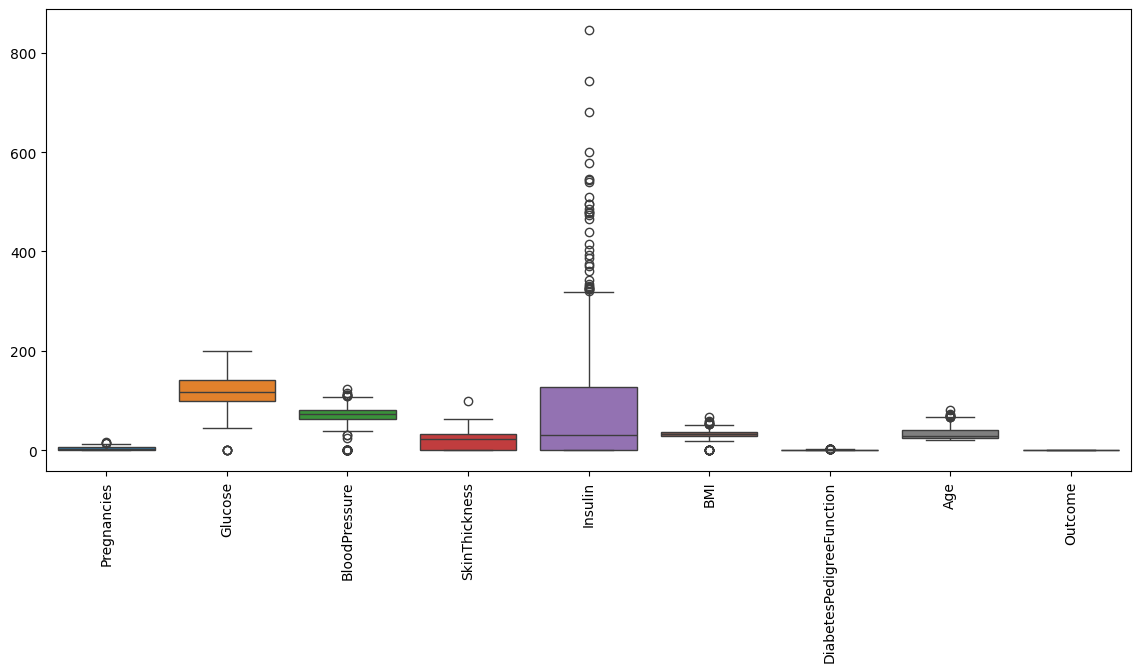

In [10]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [11]:
### outlier capping 
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

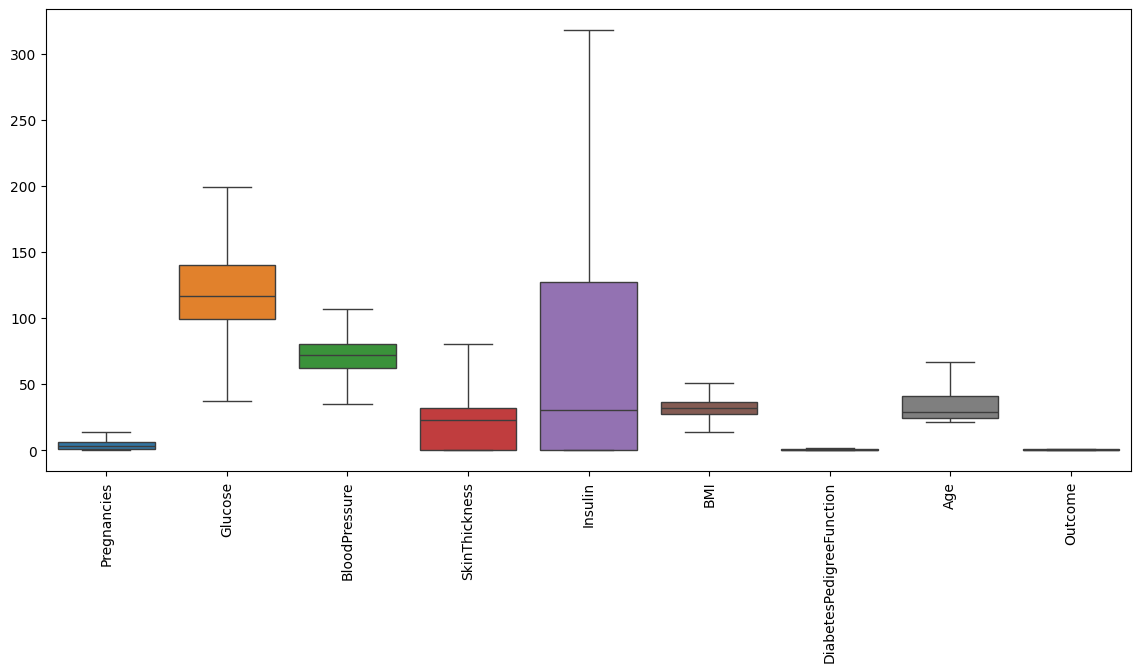

In [12]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

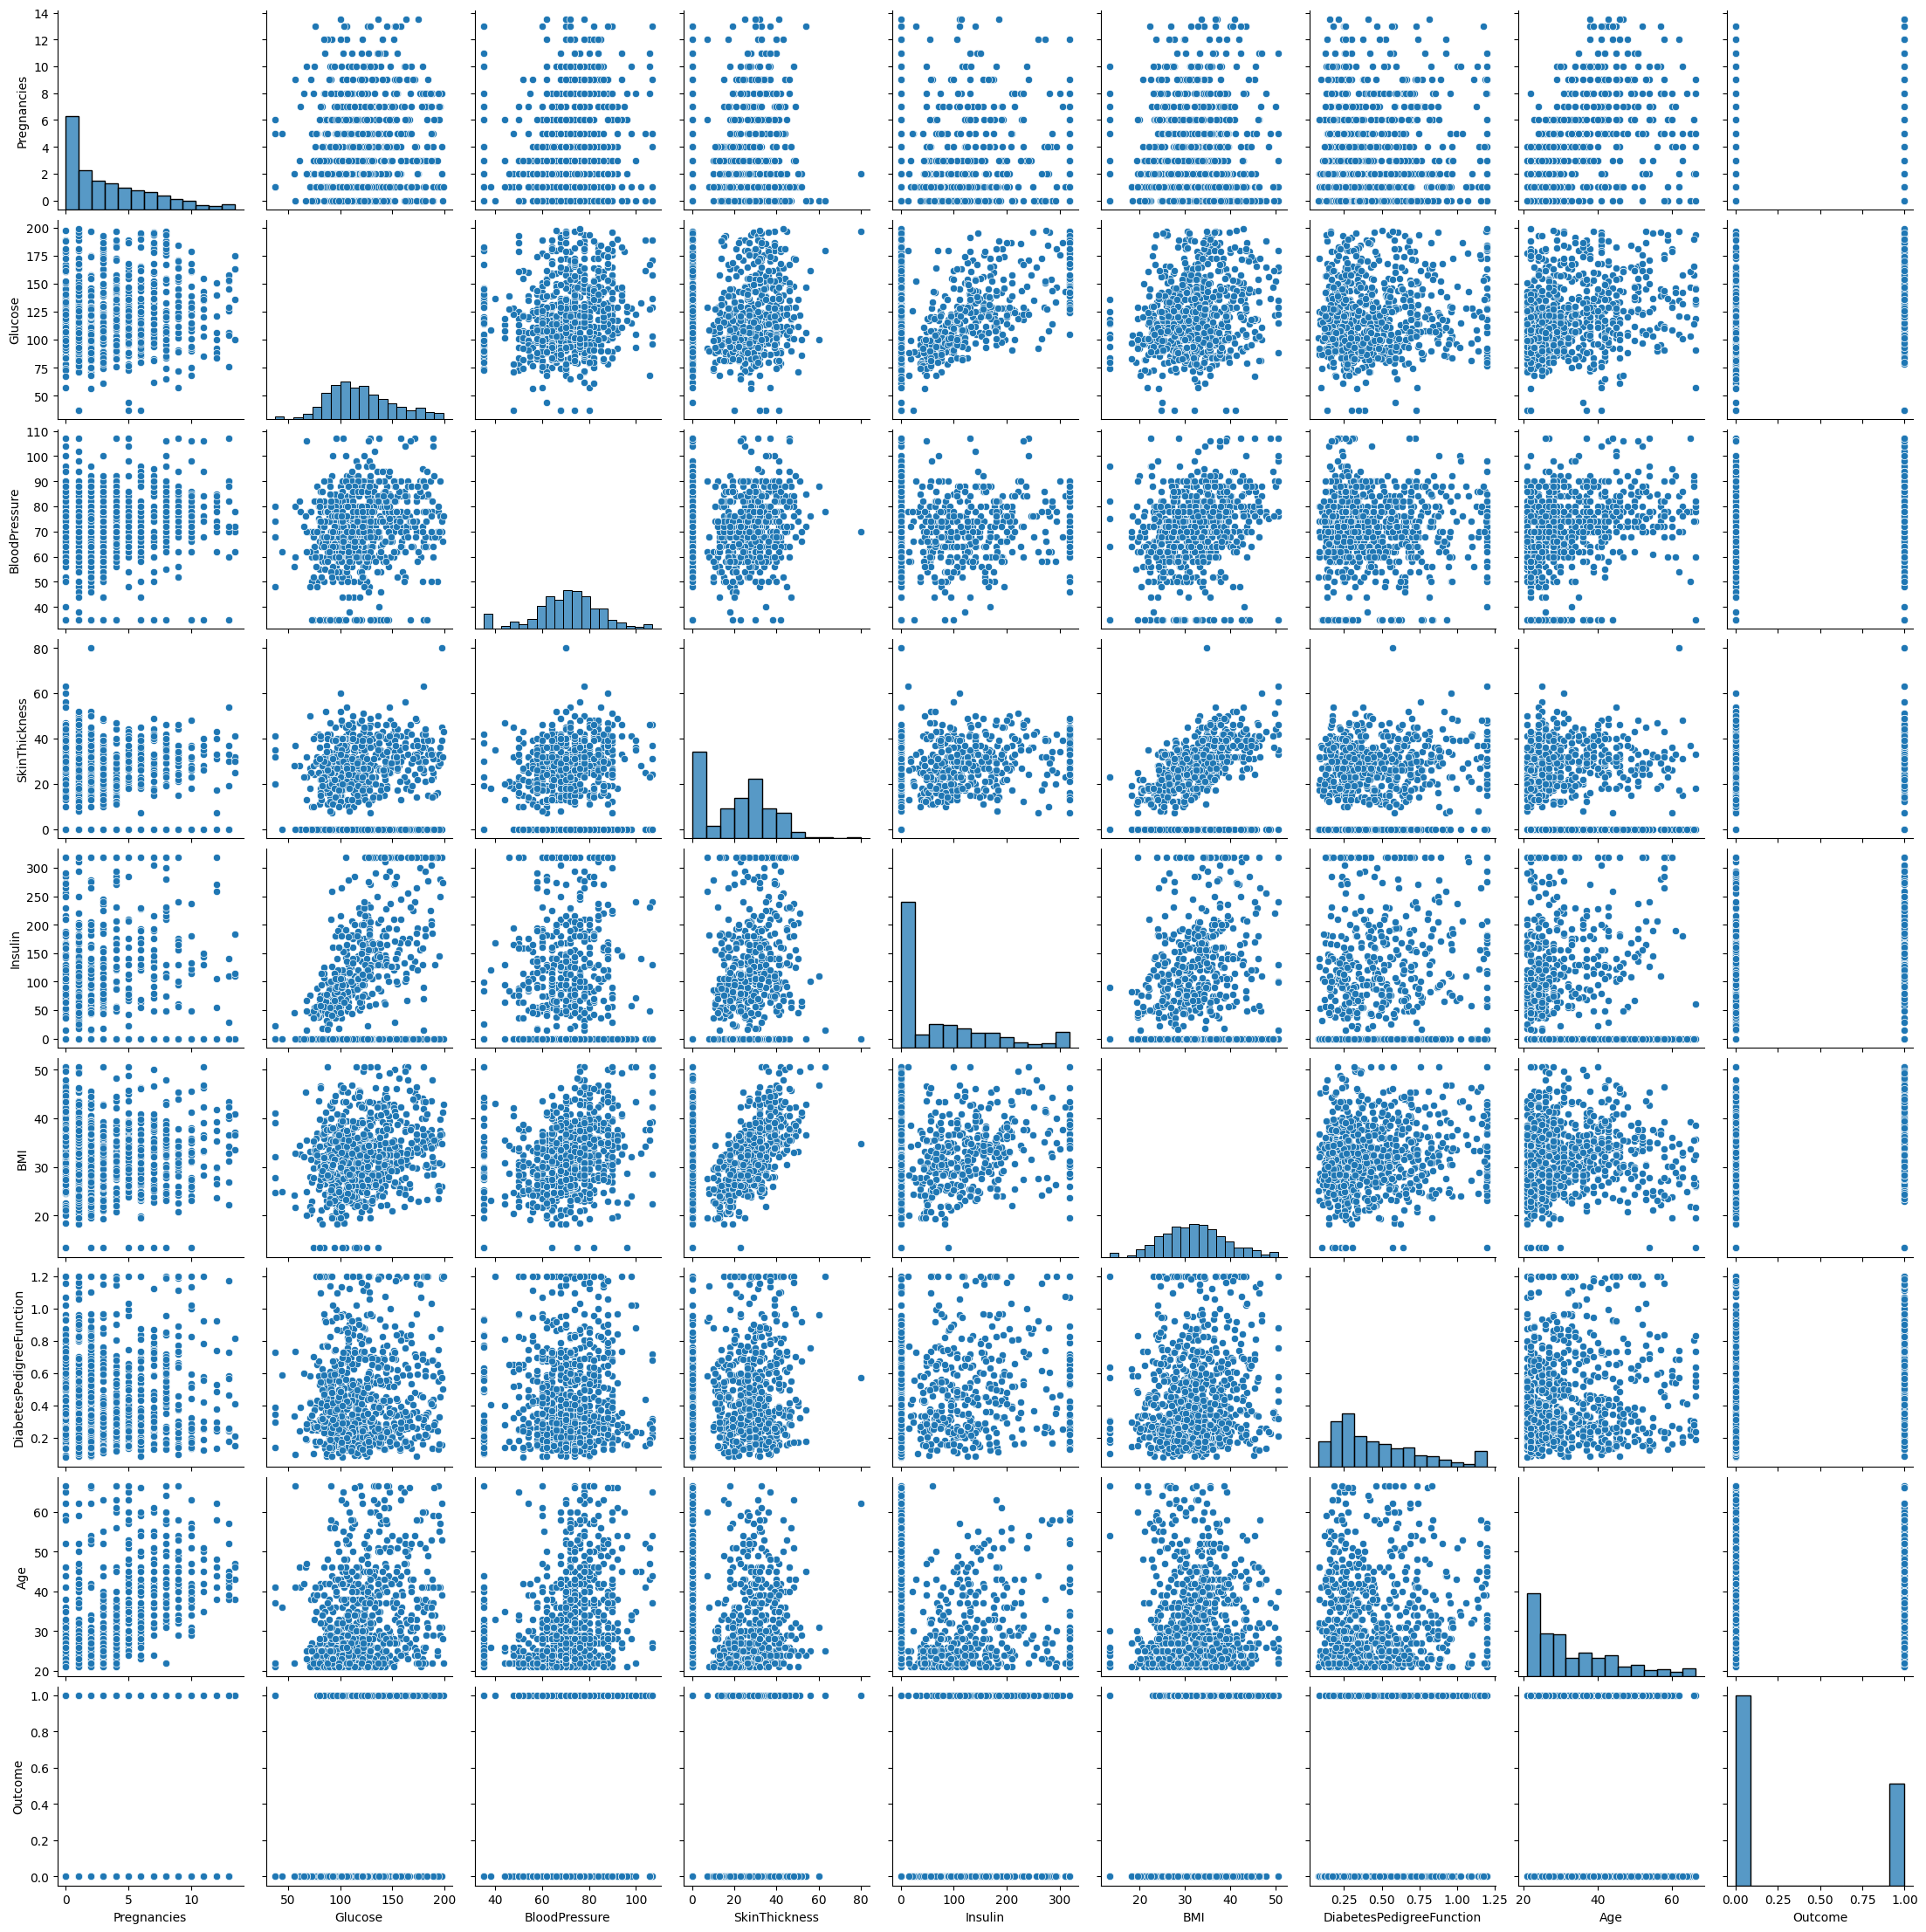

In [13]:
sns.pairplot(df)

In [14]:
target_col = "Outcome" if "Outcome" in df.columns else df.columns[-1]


In [15]:
# Visualize distributions of numeric features using histograms
numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_col]

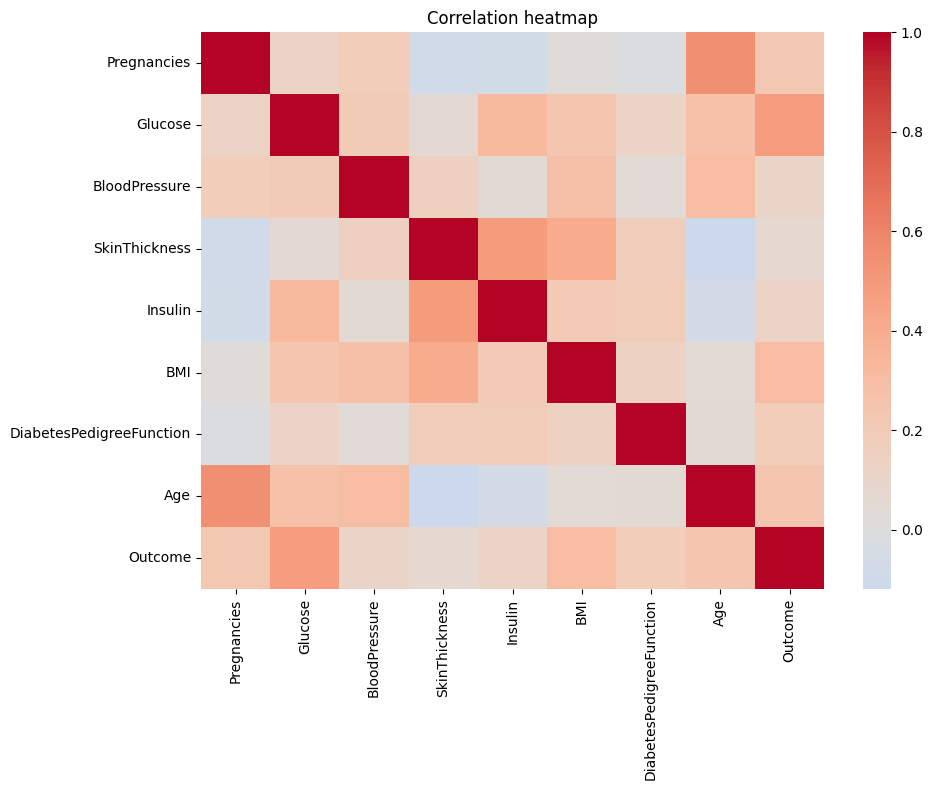

In [16]:
# Display correlation heatmap to identify feature relationships and target correlations
corr = df[feature_cols + [target_col]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()

In [17]:
corr_with_target = corr[target_col].sort_values(ascending=False)

corr_with_target

Outcome                     1.000000
Glucose                     0.479158
BMI                         0.309739
Age                         0.242702
Pregnancies                 0.220392
DiabetesPedigreeFunction    0.184969
Insulin                     0.124721
BloodPressure               0.113301
SkinThickness               0.073125
Name: Outcome, dtype: float64

In [18]:
# Import required libraries for data manipulation, visualization, and machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="whitegrid", context="notebook")

In [19]:
# Separate features and target, create preprocessing pipelines, and split data
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

# Create pipeline for numeric features: impute missing values and scale
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Create pipeline for categorical features: impute and one-hot encode
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine numeric and categorical pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

# Split data into train and test sets with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [20]:
# Create a complete pipeline combining preprocessing and logistic regression model
model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("log_reg", LogisticRegression(max_iter=1000, solver="liblinear")),
    ]
)

model

,steps,"[('preprocess', ...), ('log_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
# Train the logistic regression model on the training data
model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('log_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
# Make predictions on test data and calculate performance metrics
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate various evaluation metrics
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

metrics

{'accuracy': 0.7012987012987013,
 'precision': 0.5869565217391305,
 'recall': 0.5,
 'f1': 0.54,
 'roc_auc': 0.8227777777777777}

In [23]:
# Display confusion matrix and detailed classification report
confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



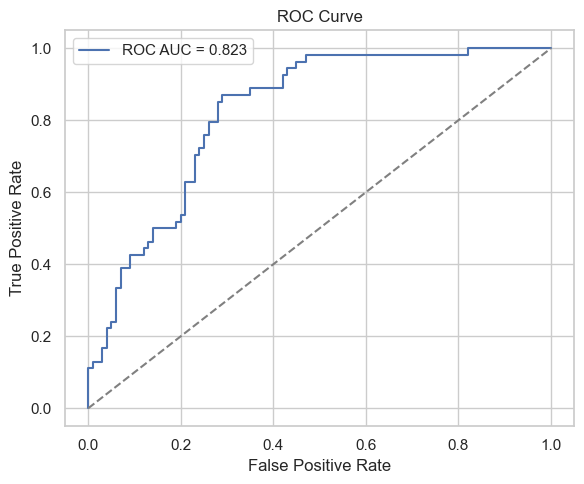

In [24]:
# Calculate and plot the ROC curve to visualize model's discrimination ability
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()

In [25]:
# Extract feature coefficients and calculate odds ratios for interpretation
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coef = model.named_steps["log_reg"].coef_[0]

# Create DataFrame with coefficients and odds ratios, sorted by coefficient magnitude
coef_df = pd.DataFrame(
    {"feature": feature_names, "coef": coef, "odds_ratio": np.exp(coef)}
).sort_values("coef", ascending=False)

(coef_df.head(10), coef_df.tail(10))

(                         feature      coef  odds_ratio
 1                   num__Glucose  1.150377    3.159383
 5                       num__BMI  0.715176    2.044546
 0               num__Pregnancies  0.367126    1.443580
 6  num__DiabetesPedigreeFunction  0.302127    1.352733
 7                       num__Age  0.183638    1.201581
 3             num__SkinThickness  0.026740    1.027100
 4                   num__Insulin -0.121632    0.885474
 2             num__BloodPressure -0.148315    0.862160,
                          feature      coef  odds_ratio
 1                   num__Glucose  1.150377    3.159383
 5                       num__BMI  0.715176    2.044546
 0               num__Pregnancies  0.367126    1.443580
 6  num__DiabetesPedigreeFunction  0.302127    1.352733
 7                       num__Age  0.183638    1.201581
 3             num__SkinThickness  0.026740    1.027100
 4                   num__Insulin -0.121632    0.885474
 2             num__BloodPressure -0.148315    

In [26]:
# Save the trained model to a file for future use and deployment
model_path = Path("diabetes_logreg.joblib")
joblib.dump(model, model_path)

model_path

WindowsPath('diabetes_logreg.joblib')

In [27]:
# Create and save a Streamlit application for model deployment
# Get unique values for categorical features
cat_values = {
    col: sorted(df[col].dropna().unique().tolist()) for col in categorical_features
}

# Generate the Streamlit app code with model loading and prediction functionality
app_code = f"""
import joblib
import pandas as pd
import streamlit as st

st.set_page_config(page_title="Diabetes Logistic Regression", layout="centered")

model = joblib.load("diabetes_logreg.joblib")

numeric_features = {numeric_features}
categorical_features = {categorical_features}
cat_values = {cat_values}

st.title("Diabetes Prediction")

with st.form("input_form"):
    inputs = {{}}
    st.subheader("Numeric inputs")
    for col in numeric_features:
        inputs[col] = st.number_input(col, value=0.0)
    if categorical_features:
        st.subheader("Categorical inputs")
        for col in categorical_features:
            options = cat_values.get(col, [])
            if options:
                inputs[col] = st.selectbox(col, options)
            else:
                inputs[col] = st.text_input(col, value="")
    submitted = st.form_submit_button("Predict")

if submitted:
    df_input = pd.DataFrame([inputs])
    proba = model.predict_proba(df_input)[:, 1][0]
    pred = int(proba >= 0.5)
    st.write(f"Prediction: {{pred}}")
    st.write(f"Probability of positive class: {{proba:.3f}}")
"""

# Write the generated code to a Streamlit app file
Path("streamlit_app.py").write_text(app_code, encoding="utf-8")

"streamlit_app.py written"

'streamlit_app.py written'